# Hands-on on MC simulations
### γ / hadron discrimination — Random Forest meets CNN
**INAF Lucchin PhD School · Spring 2026 · Antonio Pagliaro**

> **Repository:** [github.com/antopag/lucchin-handson](https://github.com/antopag/lucchin-handson)

---

This notebook is the practical companion to the lecture. It walks you through the
full workflow we sketched on the slides:

1. Load the ASTRI Mini-Array MC — Hillas parameters, real-data simulation.
2. Look at the data before doing anything else.
3. Train a Random Forest on the Hillas features. Read its feature importance.
4. Run inference with a small pre-trained CNN. Compare its ROC to the Random Forest's.
5. Discuss honestly: who wins, and *what does winning mean?*

Every cell has a verifiable output. If you fall behind, jump to the next section header
and you'll find a clean checkpoint to restart from.

If anything goes wrong: ask a neighbour first, then me.

## § 0 — Preamble: imports & version check

We use:

- **NumPy / pandas** — array manipulation
- **scikit-learn** — Random Forest
- **PyTorch** — CNN inference
- **astropy** — reading ASTRI FITS files
- **matplotlib** — plotting

If any of the version assertions below fails, the notebook may behave unexpectedly.
Upgrade with `pip install -U <package>` and try again.


In [1]:
import sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import torch
import astropy
from astropy.io import fits

warnings.filterwarnings("ignore", category=UserWarning)

print(f"Python  {sys.version.split()[0]}")
print(f"NumPy   {np.__version__}")
print(f"Pandas  {pd.__version__}")
print(f"sklearn {sklearn.__version__}")
print(f"torch   {torch.__version__}")
print(f"astropy {astropy.__version__}")

assert sys.version_info >= (3, 9),  "need Python ≥ 3.9"
assert sklearn.__version__ >= "1.0", "need scikit-learn ≥ 1.0"
assert torch.__version__ >= "1.13",  "need PyTorch ≥ 1.13"
print("\nall versions OK")


Python  3.12.13
NumPy   2.0.2
Pandas  2.2.2
sklearn 1.6.1
torch   2.10.0+cpu
astropy 7.2.0

all versions OK


## § 1 — Loading the ASTRI MC dataset

We will work with simulated events from the **ASTRI Mini-Array** at Tenerife.
The data is in FITS format (level **lv2a** = DL2 in CTAO terminology), with
shower image parameters already computed by the official A-SciSoft pipeline.

The files come in pairs:

```
MA_012_gamma_*_train.lv2a    →  γ-ray events  (label = 0)
MA_012_proton_*_train.lv2a   →  proton events (label = 1)
```

Each file is a FITS table; the `EVENTS` HDU contains one row per event with
~50 columns: shower image parameters (Hillas family + higher-order moments
+ stereo reconstruction), telescope info, MC truth.

**Note:** these are *training* MC files — they have a `GAMMANESS` column
that is empty (NaN). The whole point of this notebook is exactly to *fill it in*
with our own classifier.


### 1.1 — Set the data location

If you are running this notebook on the school server, the path is already set.
If you cloned the repo locally, point `DATA_DIR` to the folder containing the FITS
files (or to the Zenodo mirror).


In [6]:
from pathlib import Path

# ── Edit this path if needed ──────────────────────────────────────────────
#DATA_DIR = Path("./data")     # local default
# DATA_DIR = Path("/data/lucchin2026/")    # INAF server
#
# ──────────────────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = Path("/content/drive/MyDrive/LUCCHIN/data")


assert DATA_DIR.exists(), (
    f"Data directory {DATA_DIR} not found. "
    "Either clone the dataset locally or set DATA_DIR to the right path."
)

# Training files (.lv2a)
gamma_files  = sorted((DATA_DIR / "gamma" / "train").glob("MA_012_gamma_*_train.lv2a"))
proton_files = sorted((DATA_DIR / "proton" / "train").glob("MA_012_proton_*_train.lv2a"))
print(f"γ train files:      {len(gamma_files)}")
print(f"proton train files: {len(proton_files)}")
assert len(gamma_files) > 0 and len(proton_files) > 0, "no train FITS files found"

# Test files (.lv2a.fits.gz) — independent MC runs, never seen during training
gamma_test_files  = sorted((DATA_DIR / "gamma" / "test").glob("MA_012_gamma_*.lv2a.fits.gz"))
proton_test_files = sorted((DATA_DIR / "proton" / "test").glob("MA_012_proton_*.lv2a.fits.gz"))
print(f"γ test files:       {len(gamma_test_files)}")
print(f"proton test files:  {len(proton_test_files)}")
assert len(gamma_test_files) > 0 and len(proton_test_files) > 0, "no test FITS files found"

Mounted at /content/drive
γ train files:      5
proton train files: 3
γ test files:       2
proton test files:  2


### 1.2 — Read one file to understand its structure

Before processing all files, let's open one and see what's inside.


In [7]:
sample = gamma_files[0]
print(f"sample file: {sample.name}\n")

with fits.open(sample) as hdul:
    hdul.info()        # list HDUs
    print()
    # Find the table HDU containing event data
    for hdu in hdul[1:]:
        if isinstance(hdu, fits.BinTableHDU):
            print(f"HDU '{hdu.name}' columns:")
            print(f"  {hdu.columns.names}")
            break


sample file: MA_012_gamma_00001000-00001099_R_zd20-20_az000-000_train.lv2a

Filename: /content/drive/MyDrive/LUCCHIN/data/gamma/train/MA_012_gamma_00001000-00001099_R_zd20-20_az000-000_train.lv2a
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     178   ()      
  1  EVENTS        1 BinTableHDU    151   61662R x 50C   [1L, 19A, 1J, 1J, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1E, 1I, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1L, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J, 1J, 1J, 1J, 1J, J]   
  2  SIM_EVTS      1 BinTableHDU     49   1000000R x 11C   [1I, 1J, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E]   
  3  TELCONF       1 BinTableHDU     53   9R x 15C   [1J, 1J, 1E, 1E, 1E, 1E, 1E, 1J, 1E, 1E, 1E, 1J, 2368E, 2368E, 2368B]   

HDU 'EVENTS' columns:
  ['VT', 'TIME_UTC', 'TIME_S', 'TIME_NS', 'EVT_CTR', 'SIZE', 'MEANX', 'MEANY', 'LENGTH', 'WIDTH', 'DELTA', 'ASYM', 'CONC', 'MDIST', 'M3LONG', 'LEAKAGE', 'DIST', 'MISS', 'ALPH

### 1.3 — Define the feature set and load all files

The ASTRI A-SciSoft DL2 file gives us ~50 columns. For γ/hadron discrimination
we use the **shower image parameters** — the Hillas family extended with
higher-order shape moments. They are physics-motivated descriptors of the
ellipse left on the camera by the Cherenkov shower.


In [8]:
# Feature set: the seven main shower image parameters.
# These are the modern descendants of Hillas (1985) — extended with higher
# moments (M3LONG, ASYM) that capture longitudinal asymmetry of the shower.
FEATURES = ["SIZE", "LENGTH", "WIDTH", "CONC", "M3LONG", "ASYM", "MDIST"]

# Stereo features (3 telescopes seeing the same shower) — VERY discriminating.
# We keep them aside and add them in section 3.5 as a "what changes if I add these?"
# experiment.
STEREO_FEATURES = ["STMAXH", "STIP", "TELIP"]


def load_fits_events(path, columns):
    """Load a list of columns from the EVENTS HDU of one ASTRI lv2a file."""
    with fits.open(path) as hdul:
        tab = hdul["EVENTS"].data
        return pd.DataFrame({
            col: np.asarray(tab[col], dtype=np.float32)
            for col in columns
        })


def load_class(file_list, label, columns):
    """Concatenate all files for one class and assign the label."""
    dfs = [load_fits_events(f, columns) for f in file_list]
    df = pd.concat(dfs, ignore_index=True)
    df["label"] = label
    return df


t0 = time.time()
columns_to_load = FEATURES + STEREO_FEATURES   # load all, decide later which to use

# ── Training data ─────────────────────────────────────────────────────────
df_gamma  = load_class(gamma_files,  label=0, columns=columns_to_load)
df_proton = load_class(proton_files, label=1, columns=columns_to_load)
df_full   = pd.concat([df_gamma, df_proton], ignore_index=True)

# ── Independent test data ─────────────────────────────────────────────────
df_gamma_test  = load_class(gamma_test_files,  label=0, columns=columns_to_load)
df_proton_test = load_class(proton_test_files, label=1, columns=columns_to_load)
df_test_raw    = pd.concat([df_gamma_test, df_proton_test], ignore_index=True)

print(f"loaded in {time.time()-t0:.1f}s")
print(f"\n  Training set:")
print(f"    γ events:      {len(df_gamma):>7,d}")
print(f"    proton events: {len(df_proton):>7,d}")
print(f"    total:         {len(df_full):>7,d}")
print(f"\n  Independent test set:")
print(f"    γ events:      {len(df_gamma_test):>7,d}")
print(f"    proton events: {len(df_proton_test):>7,d}")
print(f"    total:         {len(df_test_raw):>7,d}")

loaded in 28.1s

  Training set:
    γ events:      305,870
    proton events: 371,084
    total:         676,954

  Independent test set:
    γ events:      123,277
    proton events: 248,362
    total:         371,639


### 1.4 — Sanity check: NaNs and infinities

Real-world FITS files have surprises. Stereo reconstruction fails for events
seen by only one telescope, leaving NaNs in the stereo columns. Outliers
also do strange things. Let's see what's actually there before training anything.


In [9]:
print("NaN counts per column (training set):")
print(df_full.isna().sum())
print(f"\ninfinity counts:")
print(np.isinf(df_full.select_dtypes(include=[np.number])).sum())

# Drop rows with any NaN/inf in our selected features
feat_data = df_full[FEATURES + ["label"]]
n_before = len(feat_data)
feat_data = feat_data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
n_after = len(feat_data)
print(f"\n{n_before-n_after:,} rows dropped ({100*(n_before-n_after)/n_before:.2f}%)")
print(f"clean training set: {n_after:,} rows")

# Class balance after cleaning
print(f"\n  γ remaining:      {(feat_data.label==0).sum():>7,d}")
print(f"  proton remaining: {(feat_data.label==1).sum():>7,d}")

# Replace df_full with the clean version — from here on this is what we use
df_full = feat_data

# ── Clean the independent test set the same way ──────────────────────────
test_data = df_test_raw[FEATURES + ["label"]]
n_before_t = len(test_data)
test_data = test_data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
n_after_t = len(test_data)
print(f"\nIndependent test set: {n_before_t-n_after_t:,} rows dropped ({100*(n_before_t-n_after_t)/n_before_t:.2f}%)")
print(f"clean test set: {n_after_t:,} rows")
df_indep_test = test_data

NaN counts per column (training set):
SIZE           0
LENGTH         0
WIDTH          0
CONC           0
M3LONG         0
ASYM           0
MDIST          0
STMAXH    120025
STIP      120025
TELIP     120025
label          0
dtype: int64

infinity counts:
SIZE      0
LENGTH    0
WIDTH     0
CONC      0
M3LONG    0
ASYM      0
MDIST     0
STMAXH    0
STIP      0
TELIP     0
label     0
dtype: int64

0 rows dropped (0.00%)
clean training set: 676,954 rows

  γ remaining:      305,870
  proton remaining: 371,084

Independent test set: 0 rows dropped (0.00%)
clean test set: 371,639 rows


## § 2 — Visual exploration

> The 90% who skip this step regret it later.

Before training anything, look at the data. Just look. We want to know:

1. Are the two classes statistically different in some Hillas parameter?
2. Where does the "gap" between the distributions close?
3. Are there obvious outliers, NaNs, infinities?

If the gap is so big you could classify by eye, the ML problem is trivial.
If it's so small you can't see anything, you have a hard problem.
The truth is usually somewhere in between — and we want to *see* where.


### 2.1 — Distribution of each Hillas parameter, γ vs proton


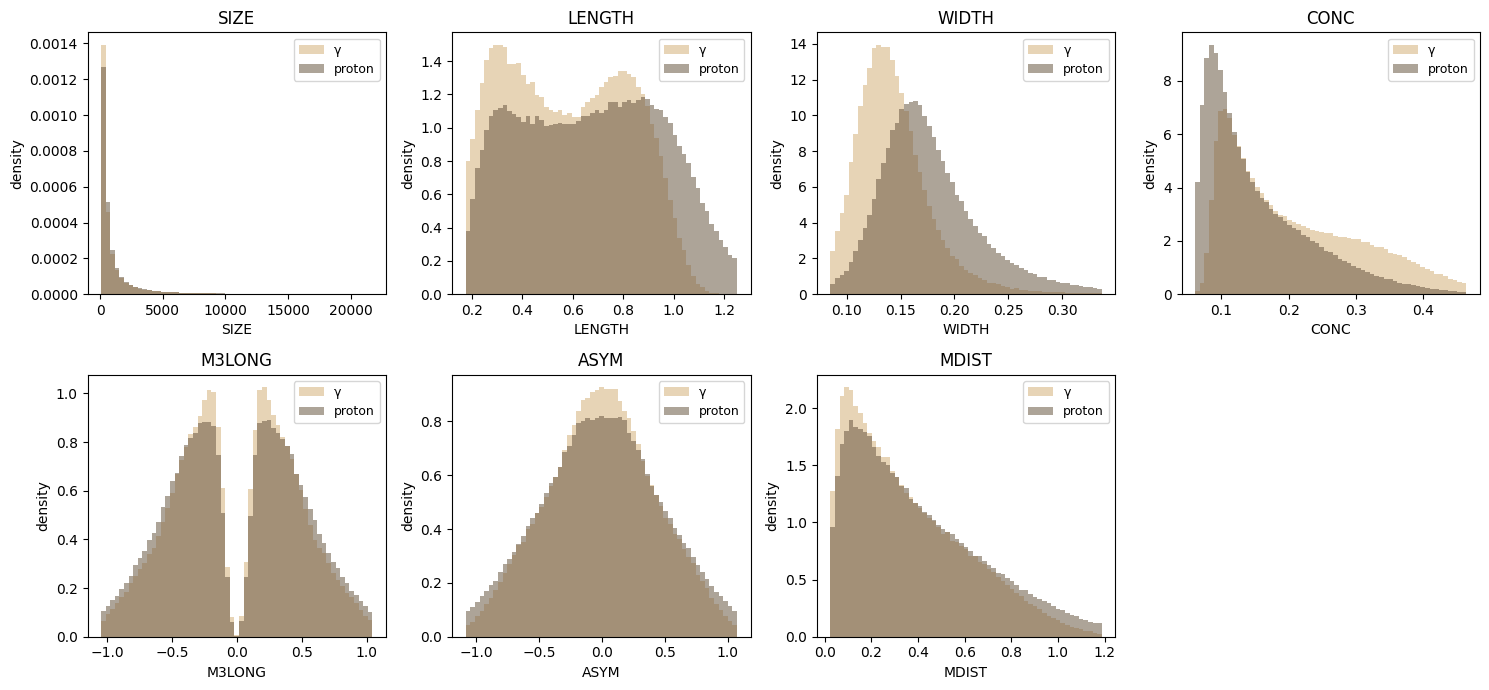

In [10]:
features = FEATURES   # SIZE, LENGTH, WIDTH, CONC, M3LONG, ASYM, MDIST
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    g = df_full.loc[df_full.label == 0, feat]
    p = df_full.loc[df_full.label == 1, feat]
    # Use 1st-99th percentile to avoid extreme outliers compressing the plot
    lo, hi = np.percentile(np.concatenate([g, p]), [1, 99])
    bins = np.linspace(lo, hi, 60)

    ax.hist(g, bins=bins, alpha=0.55, label="γ",      color="#D4B27A", density=True)
    ax.hist(p, bins=bins, alpha=0.55, label="proton", color="#6B5944", density=True)
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel(feat); ax.set_ylabel("density")
    ax.legend(fontsize=9)

# Hide unused subplots (we have 7 features in a 2x4 grid → 1 empty)
for ax in axes[len(features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


**Pause for thought.** Look at each panel. Which features show a clear gap between
γ and proton? Which don't? You should be able to predict — *before training* —
which features the Random Forest will rely on.


### 2.2 — A 2D scatter: WIDTH vs LENGTH

Two of the most discriminating parameters, plotted against each other.
The shape of the two clouds tells you a lot.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
g = df_full[df_full.label == 0].sample(min(2000, sum(df_full.label == 0)), random_state=42)
p = df_full[df_full.label == 1].sample(min(2000, sum(df_full.label == 1)), random_state=42)

ax.scatter(g.WIDTH, g.LENGTH, s=8, alpha=0.4, c="#D4B27A", label="γ")
ax.scatter(p.WIDTH, p.LENGTH, s=8, alpha=0.4, c="#6B5944", label="proton")
ax.set_xlabel("WIDTH"); ax.set_ylabel("LENGTH")
ax.set_title("Hillas WIDTH vs LENGTH — 2,000 events per class")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## § 3 — Random Forest on Hillas parameters

Now we train a classifier. The recipe is three lines.

The Hillas parameters are *good features* — somebody (Hillas himself, in 1985)
already did the hard work of compressing seventy years of physical intuition into
six numbers. So we expect the Random Forest to perform well.


### 3.1 — Train/test split


In [ ]:
from sklearn.model_selection import train_test_split

X = df_full[features].values
y = df_full["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42,
)
print(f"train: {len(X_train):,}   test: {len(X_test):,}")
print(f"class balance in train:  γ={int((y_train==0).sum())}  p={int((y_train==1).sum())}")


### 3.2 — Fit the Random Forest


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
)

t0 = time.time()
rf.fit(X_train, y_train)
print(f"trained {len(rf.estimators_)} trees in {time.time()-t0:.2f}s")


### 3.3 — Performance: ROC and AUC


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# We use predict_proba — the score that becomes "γ-ness"
rf_score = rf.predict_proba(X_test)[:, 0]   # column 0 = P(γ)

# Convention: positive class = γ → label 0 → use 1 - y_test
y_gamma = (y_test == 0).astype(int)
fpr_rf, tpr_rf, _ = roc_curve(y_gamma, rf_score)
auc_rf = roc_auc_score(y_gamma, rf_score)

print(f"AUC (Random Forest, γ vs hadron): {auc_rf:.4f}")
print()
print(classification_report(y_test, rf.predict(X_test),
                            target_names=["γ", "proton"], digits=3))


In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_rf, tpr_rf, color="#D4B27A", lw=2, label=f"Random Forest (AUC = {auc_rf:.3f})")
ax.plot([0, 1], [0, 1], "--", color="#8A7B62", lw=1, label="random")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC — Random Forest on Hillas")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3.3b — Independent test: does it generalise?

The ROC above was computed on a random 30% split of the *same* MC runs.
Now we evaluate on **completely independent MC runs** that the model has
never seen — not even indirectly through the train/test split. This is
a much harder (and more honest) test.

In [ ]:
X_indep = df_indep_test[features].values
y_indep = df_indep_test["label"].values

rf_score_indep = rf.predict_proba(X_indep)[:, 0]
y_gamma_indep = (y_indep == 0).astype(int)
fpr_rf_indep, tpr_rf_indep, _ = roc_curve(y_gamma_indep, rf_score_indep)
auc_rf_indep = roc_auc_score(y_gamma_indep, rf_score_indep)

print(f"AUC on random split:       {auc_rf:.4f}  ({len(X_test):,} events)")
print(f"AUC on independent test:   {auc_rf_indep:.4f}  ({len(X_indep):,} events)")
print(f"difference: {(auc_rf_indep - auc_rf)*100:+.2f} pp")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_rf, tpr_rf, color="#D4B27A", lw=2,
        label=f"random split (AUC = {auc_rf:.3f})")
ax.plot(fpr_rf_indep, tpr_rf_indep, color="#8A5A2B", lw=2, ls="--",
        label=f"independent test (AUC = {auc_rf_indep:.3f})")
ax.plot([0, 1], [0, 1], ":", color="#8A7B62", lw=1, label="random")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("Random Forest — split test vs independent test")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 — Feature importance: what did the model look at?

This is the cell I want you to remember. The model tells you, *for free*,
which features it weighted most heavily in its decisions.

If the bar plot below ranks the features in a physically sensible order
(e.g. WIDTH and LENGTH on top, ALPHA somewhere in the middle, CONC at the
bottom), you have a model that learned what we expected. If the order looks
weird — that's not a bad thing, that's a *signal* worth investigating.


In [ ]:
imp = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values, color="#D4B27A", edgecolor="#8A7B62")
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Which features did the model use?")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nfeature importance (sorted):")
for f, v in imp[::-1].items():
    print(f"  {f:8s}  {v:.4f}")


### 3.4-bis — From AUC to a working cut: purity vs efficiency

The Random Forest gives us a probability that each event is a γ — the
**gammaness** score. So far we have only computed the AUC, which is one
number that summarises the whole ROC curve.

But in real life nobody analyses events at "AUC = 0.97". You analyse
events that survive a **cut on gammaness**. So the operational question
is:

> *What gammaness threshold do I choose, and what do I get out of it?*

The answer is a trade-off. A loose cut keeps almost all γ events but lets
many protons through (low purity, high efficiency). A tight cut keeps
only the most γ-like events, throwing away genuine γ in the process
(high purity, low efficiency). The optimal cut depends on what you are
trying to measure.

Let's see this trade-off explicitly.

In [ ]:
from sklearn.metrics import roc_curve

# rf_score is already defined: probability of being γ
# y_gamma is already defined: 1 if true γ, 0 if true proton

thresholds = np.linspace(0.05, 0.95, 91)
n_gamma_total = (y_gamma == 1).sum()
n_proton_total = (y_gamma == 0).sum()

efficiency = []   # γ kept / γ total
purity = []       # γ kept / (γ kept + protons kept)
significance = [] # gamma_kept / sqrt(proton_kept)  — Li & Ma simplified

for t in thresholds:
    mask = rf_score >= t
    n_g_kept = ((y_gamma == 1) & mask).sum()
    n_p_kept = ((y_gamma == 0) & mask).sum()
    eff = n_g_kept / n_gamma_total
    pur = n_g_kept / (n_g_kept + n_p_kept) if (n_g_kept + n_p_kept) > 0 else 0
    # Naive significance proxy: signal / sqrt(background)
    sig = n_g_kept / np.sqrt(n_p_kept) if n_p_kept > 0 else 0
    efficiency.append(eff)
    purity.append(pur)
    significance.append(sig)

efficiency = np.array(efficiency)
purity = np.array(purity)
significance = np.array(significance)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: efficiency and purity vs threshold
axes[0].plot(thresholds, efficiency, color="#D4B27A", lw=2, label="γ efficiency")
axes[0].plot(thresholds, purity, color="#6B5944", lw=2, label="γ purity")
axes[0].set_xlabel("gammaness threshold")
axes[0].set_ylabel("fraction")
axes[0].set_title("Efficiency and purity vs cut")
axes[0].legend(loc="center left")
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Right: significance proxy vs threshold
axes[1].plot(thresholds, significance, color="#A47D3F", lw=2)
best_idx = int(np.argmax(significance))
best_t = thresholds[best_idx]
axes[1].axvline(best_t, color="#8A6E3F", ls="--", lw=1)
axes[1].set_xlabel("gammaness threshold")
axes[1].set_ylabel("S / √B  (illustrative)")
axes[1].set_title(f"Significance proxy — peaks at threshold ≈ {best_t:.2f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAt the optimal cut (threshold = {best_t:.2f}):")
print(f"  γ efficiency:  {efficiency[best_idx]:.3f}")
print(f"  γ purity:      {purity[best_idx]:.3f}")
print(f"  events kept:   {int(efficiency[best_idx] * n_gamma_total)} γ, " +
      f"{int((1-purity[best_idx])/purity[best_idx] * efficiency[best_idx] * n_gamma_total)} protons")

**Pause for thought.**

- The AUC was 0.97 — a single number. The plots above tell a much richer
  story: that single number hides hundreds of operational decisions.
- The "optimal" threshold I picked maximises a naive `S / √B`. In a real
  γ-ray analysis you would use the full Li & Ma formula and you would
  account for the energy-dependent flux of γ vs cosmic rays. The cut that
  is optimal for a 1 TeV bright source is not the cut that is optimal
  for a faint 100 GeV source.
- **The lesson:** the ML model gives you a score. The science decision
  is in the cut. They are different responsibilities.

### 3.5 — *(Bonus)* What if we add stereo reconstruction features?

The ASTRI Mini-Array is a *stereoscopic* array — multiple telescopes see the
same shower from different angles. From this we can reconstruct **3D shower
parameters** that no single-telescope analysis could ever access:

| Feature | Meaning |
|---|---|
| `STMAXH` | maximum height of the shower in the atmosphere |
| `STIP`   | impact parameter on the ground |
| `TELIP`  | per-telescope impact distance |

These are very discriminating. Let's see by how much they improve the model.


In [ ]:
# Re-load with stereo features included, and clean
EXTENDED = FEATURES + STEREO_FEATURES
ext_data = df_full.copy()   # has FEATURES + label
# Pull stereo cols from the originally loaded df_gamma/df_proton — they still have them
df_full_with_stereo = pd.concat([df_gamma, df_proton], ignore_index=True)
df_full_with_stereo = df_full_with_stereo[EXTENDED + ["label"]]
df_full_with_stereo = df_full_with_stereo.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f"events with all stereo features: {len(df_full_with_stereo):,}")

X_ext = df_full_with_stereo[EXTENDED].values
y_ext = df_full_with_stereo["label"].values

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_ext, y_ext, test_size=0.30, stratify=y_ext, random_state=42
)

rf_ext = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
t0 = time.time()
rf_ext.fit(X_train_e, y_train_e)
print(f"trained in {time.time()-t0:.2f}s")

rf_ext_score = rf_ext.predict_proba(X_test_e)[:, 0]
auc_rf_ext = roc_auc_score((y_test_e == 0).astype(int), rf_ext_score)
print(f"\nAUC without stereo features: {auc_rf:.4f}")
print(f"AUC with stereo features:    {auc_rf_ext:.4f}")
print(f"improvement: {(auc_rf_ext - auc_rf)*100:+.2f} percentage points")


In [ ]:
imp_ext = pd.Series(rf_ext.feature_importances_, index=EXTENDED).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#D4B27A" if f in FEATURES else "#8A5A2B" for f in imp_ext.index]
ax.barh(imp_ext.index, imp_ext.values, color=colors, edgecolor="#5A4A30")
ax.set_xlabel("feature importance — Random Forest with stereo features")
ax.set_title("Where does discrimination come from now?")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Tan = single-telescope shower image parameters")
print("Brown = stereo reconstruction parameters")


**A pause for thought.** Look at the new feature importance ranking.

- Did adding stereo features push the AUC noticeably?
- Are the stereo features now *dominant*, or do the classical Hillas-family
  features still hold their ground?
- If you had to give up half of these features, which would you keep?

The "right" answer depends on the energy regime, the source, the analysis
goal. There is no universal answer — only defensible choices.


### 3.7 — A trap to avoid: when the model learns the bookkeeping

The lecture spent a slide explaining why ALPHA must never go into the
training set: it presupposes the source position, and it is the parameter
on which the standard analysis is built downstream.

There is another, more subtle trap. The MC files contain a column called
**MCRUNNUM** — the run number of the simulation that produced each
event. It is bookkeeping metadata. It has no physical meaning.

Watch what happens if we accidentally include it in the training set.

In [ ]:
# Reload the data with MCRUNNUM included this time
columns_with_runnum = FEATURES + ["MCRUNNUM"]

df_with_runnum = pd.concat([
    load_class(gamma_files, label=0, columns=columns_with_runnum),
    load_class(proton_files, label=1, columns=columns_with_runnum),
], ignore_index=True)
df_with_runnum = df_with_runnum.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

X_leak = df_with_runnum[FEATURES + ["MCRUNNUM"]].values
y_leak = df_with_runnum["label"].values

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y_leak, test_size=0.30, stratify=y_leak, random_state=42
)

rf_leak = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf_leak.fit(X_train_l, y_train_l)

leak_score = rf_leak.predict_proba(X_test_l)[:, 0]
auc_leak = roc_auc_score((y_test_l == 0).astype(int), leak_score)

print(f"AUC without MCRUNNUM (clean):     {auc_rf:.4f}")
print(f"AUC with MCRUNNUM in features:    {auc_leak:.4f}")
print(f"\"improvement\":                    {(auc_leak - auc_rf)*100:+.2f} percentage points")

In [ ]:
imp_leak = pd.Series(
    rf_leak.feature_importances_,
    index=FEATURES + ["MCRUNNUM"]
).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#D4B27A" if f != "MCRUNNUM" else "#8A2A2A" for f in imp_leak.index]
ax.barh(imp_leak.index, imp_leak.values, color=colors, edgecolor="#5A4A30")
ax.set_xlabel("feature importance — Random Forest with MCRUNNUM included")
ax.set_title("Where does the discrimination come from?")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**What just happened.**

The AUC went up. The classifier seems "better". But look at the bar plot:
the most important feature is now `MCRUNNUM` — a column that has no
physical meaning at all.

What is going on? The MC was generated in batches. γ events come from
some run numbers, protons from others. The Random Forest discovered this
correlation and used it. It is *not* discriminating γ from hadrons. It is
discriminating "events from γ-runs" from "events from proton-runs".

On a real ASTRI observation there is no MCRUNNUM. The classifier would
collapse to random.

**This is data leakage.** It is the most common silent failure mode in
applied ML. The defence is exactly what we just did: look at feature
importance every time, and ask if the top feature *makes physical sense*.

This is the operational version of the slide-27 message about ALPHA.
There the leakage was conceptual. Here you saw it happen.

## § 4 — A CNN trained while you slept

For the deep-learning side, we work on a *synthetic* dataset of Cherenkov-like
camera images (56×56 pixels). They are not real ASTRI camera frames — they
are statistical surrogates designed to mimic the gross visual properties
(γ are narrow and elongated and point at the source, protons are broader
and randomly oriented). The point is to give you a working CNN end-to-end
without forcing you to install hexagonal-convolution libraries.

The model is a small CNN with **25,666 parameters** and was already trained
for you. We will only run inference here.


### 4.1 — Generate the synthetic dataset


In [ ]:
from synth_camera import generate_dataset

# A modest test set — 1000 events per class is enough for a stable AUC
X_imgs, y_imgs = generate_dataset(n_per_class=1000, seed=2026)
print(f"images: {X_imgs.shape}   labels: {y_imgs.shape}")
print(f"intensity range: [{X_imgs.min():.3f}, {X_imgs.max():.3f}]")
print(f"γ:      {int((y_imgs==0).sum())}")
print(f"proton: {int((y_imgs==1).sum())}")


### 4.2 — Look at example images

Same principle as section 2: before doing anything, look.


In [ ]:
gamma_idx  = np.where(y_imgs == 0)[0][:4]
proton_idx = np.where(y_imgs == 1)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
for i, idx in enumerate(gamma_idx):
    axes[0, i].imshow(X_imgs[idx, 0], cmap="inferno", interpolation="nearest")
    axes[0, i].set_title(f"γ #{idx}", fontsize=10)
    axes[0, i].axis("off")
for i, idx in enumerate(proton_idx):
    axes[1, i].imshow(X_imgs[idx, 0], cmap="inferno", interpolation="nearest")
    axes[1, i].set_title(f"proton #{idx}", fontsize=10)
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


### 4.3 — Load the pre-trained CNN


In [ ]:
from toy_cnn import ToyCherenkovCNN

ckpt = torch.load("toy_cnn.pt", weights_only=True, map_location="cpu")

model = ToyCherenkovCNN(n_classes=2)
model.load_state_dict(ckpt["state_dict"])
model.eval()

print(f"loaded model: {ckpt['arch']}")
print(f"  parameters:  {ckpt['n_params']:,}")
print(f"  input shape: {ckpt['input_shape']}")
print(f"  trained on:  {ckpt.get('training_data', 'unspecified')}")
print()
print(model)


### 4.4 — Run inference and compute the ROC


In [ ]:
X_imgs_t = torch.from_numpy(X_imgs)

t0 = time.time()
with torch.no_grad():
    # Process in batches to keep memory low
    all_probs = []
    for i in range(0, len(X_imgs_t), 128):
        logits = model(X_imgs_t[i:i+128])
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.numpy())
cnn_probs = np.concatenate(all_probs, axis=0)
print(f"inference time: {time.time()-t0:.2f}s for {len(X_imgs)} events")

cnn_score = cnn_probs[:, 0]   # P(γ)
y_gamma_imgs = (y_imgs == 0).astype(int)
fpr_cnn, tpr_cnn, _ = roc_curve(y_gamma_imgs, cnn_score)
auc_cnn = roc_auc_score(y_gamma_imgs, cnn_score)
print(f"\nAUC (CNN, γ vs hadron, on synthetic data): {auc_cnn:.4f}")


### 4.5 — Compare ROCs


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_rf,  tpr_rf,  color="#D4B27A", lw=2,
        label=f"Random Forest on Hillas (AUC = {auc_rf:.3f})")
ax.plot(fpr_cnn, tpr_cnn, color="#B89E78", lw=2, ls="--",
        label=f"CNN on pixels (AUC = {auc_cnn:.3f})")
ax.plot([0, 1], [0, 1], color="#8A7B62", lw=1, ls=":", label="random")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("Two lenses on the same problem")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


> **An important honesty check.** The two ROC curves above were computed on
> *different datasets*: the Random Forest on real ASTRI MC, the CNN on
> synthetic surrogates. So the comparison is **not apples-to-apples**.
> You will see the CNN AUC very close to 1.0 — that's because synthetic
> images are easier than real Cherenkov physics. This is the central lesson
> of slide 44: anything the classifier learns *too well* on the MC is a
> candidate systematic on real data.


## § 5 — The verdict (or rather, the question)

Now we fill in the table from slide 43 with the numbers we have.


In [ ]:
verdict = pd.DataFrame({
    "metric": [
        "AUC",
        "training set size",
        "inference dataset",
        "interpretability",
        "training time",
    ],
    "Random Forest (Hillas)": [
        f"{auc_rf:.3f}",
        f"{len(X_train):,}",
        "real ASTRI MC",
        "feature importance ✓",
        "seconds",
    ],
    "CNN (pixels)": [
        f"{auc_cnn:.3f}",
        "(pre-trained)",
        "synthetic",
        "Grad-CAM (see § 6)",
        "tens of minutes",
    ],
})
verdict.set_index("metric")


**Discussion questions** (let's tackle these together):

1. Look at the AUCs. Does the CNN really "win"? Why is the comparison hard?
2. The Random Forest's feature importance gave you something tangible — a
   ranking your colleagues can argue with. What is the equivalent for the CNN?
3. If you had to put one of these models in tonight's analysis pipeline,
   which would you choose? **The honest answer is not "the one with the
   highest AUC."** It's the one you trust most when you cross from MC to
   real data. Why?


## § 6 — Bonus: opening the black box (optional)

If you have time, here's a starting point for **Grad-CAM** — a technique that
produces a heatmap showing where in the input image the CNN is "looking" to
make its decision. The full implementation is left as an exercise for the
curious; the cell below is a skeleton.

This is one of the threads we pull on in the **MADELEinE** programme and
the `astro-xai-bench` framework — come find me after the lecture if you want to
hear more.


In [ ]:
# ── Skeleton: Grad-CAM in 5 conceptual steps ─────────────────────────────
#
#   1.  Pick an event (one γ correctly classified, one proton misclassified
#       are the most instructive).
#
#   2.  Hook the activations and gradients of the LAST conv layer:
#         model.features[-3].register_forward_hook(...)
#         model.features[-3].register_full_backward_hook(...)
#
#   3.  Forward pass to get logits for the predicted class, then
#       loss = logits[:, predicted_class].sum() ;  loss.backward()
#
#   4.  Compute the importance weight per channel:
#         alpha_k = grad_activations.mean(dim=(2, 3))      # GAP of grad
#       and combine with the activations:
#         cam = ReLU( sum_k  alpha_k * activations_k )
#
#   5.  Upsample the cam to the input image size, overlay with imshow + alpha.
#
# Useful library: pytorch-grad-cam  (pip install grad-cam)
# Reference: Selvaraju et al., "Grad-CAM", ICCV 2017
# ──────────────────────────────────────────────────────────────────────────

print("Grad-CAM stub — implement at home, or come find me to discuss.")


---

## Where to go from here

- **Try other ensemble methods** — `ExtraTreesClassifier` is the obvious one.
  Does it beat the Random Forest? By how much?
- **Replace the synthetic CNN images with real ones** — the proper ASTRI
  camera frames have hexagonal pixels; converting them to a square grid is
  a research question in itself.
- **Read about the failure modes** — the slides mentioned MC-vs-real
  systematics, Grad-CAM diagnostics, and cross-representation plausibility.
  These are open problems.

If anything in this notebook felt magical, write it down and ask me.
The whole point of the lecture was that there should be no magic — only
choices, each one defensible.

— Antonio


### Homework: how does the model perform vs energy?

The single AUC number we computed averages over all energies. But Cherenkov
arrays do not perform uniformly: at low energies (small `SIZE`) showers
have few photoelectrons and are noisy; at high energies they are clean
and well-reconstructed.

Splitting the test set into bins of `SIZE` (a proxy for energy) and
recomputing the AUC bin by bin is one of the most informative things you
can do with this dataset. It tells you the *energy threshold* below which
your classifier breaks down — which is what determines the sensitivity of
your instrument.

Try it at home. The skeleton is below.

In [ ]:
# ── Homework — performance vs energy ─────────────────────────────────
#
# Skeleton:
#
# 1.  Define SIZE bins, e.g. logarithmically:
#         size_bins = np.logspace(np.log10(50), np.log10(2000), 8)
#
# 2.  For each bin, select test events whose SIZE is in that bin:
#         mask_bin = (X_test[:, FEATURES.index("SIZE")] >= lo) & \
#                    (X_test[:, FEATURES.index("SIZE")] <  hi)
#
# 3.  Recompute the AUC on that subset only:
#         auc_bin = roc_auc_score((y_test[mask_bin] == 0).astype(int),
#                                 rf_score[mask_bin])
#
# 4.  Plot AUC vs bin centre. Compare against the integrated AUC.
#
# Expected qualitative outcome:
#     - low-SIZE bins  → AUC much closer to 0.5 (model struggles)
#     - high-SIZE bins → AUC approaches 1.0 (model is excellent)
#
# Real bonus question: what does this tell you about the energy threshold
# of your analysis pipeline?
#
# Implement it. Show me the plot when we meet again.

pass